### Lab 8: Decision Trees
8.3.1 Fitting Classification Trees

BASE TREE PERFORMANCE
Number of terminal nodes: 33
Test Accuracy (Unpruned): 0.7350

CROSS-VALIDATION RESULTS
Best ccp_alpha found: 0.000000

PRUNED TREE PERFORMANCE
Number of terminal nodes: 33
Test Accuracy (Pruned)  : 0.7350

Confusion Matrix:
          Pred No  Pred Yes
True No        94        32
True Yes       21        53


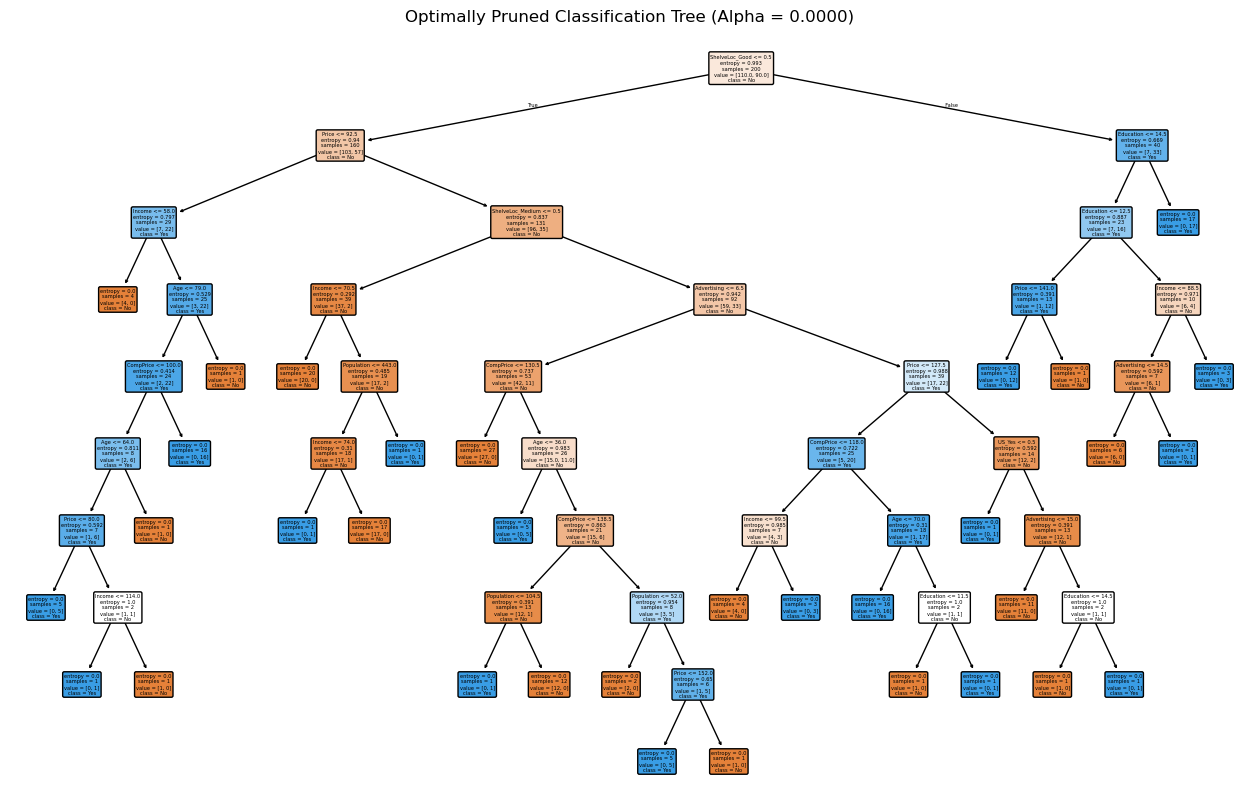

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


# 1. Load data
carseats = pd.read_csv("data/Carseats.csv")

# Создаем бинарный целевой признак High (Sales > 8)
carseats["High"] = np.where(carseats["Sales"] > 8, "Yes", "No")

# Remove Sales variable
X = carseats.drop(columns=["Sales", "High"])
y = carseats["High"]

# Coding categorical features (ShelveLoc, Urban, US) One-Hot Encoding
X = pd.get_dummies(X, columns=["ShelveLoc", "Urban", "US"], drop_first=True)

# 2. Dividing train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200, random_state=2)

# 3. Fit base model
base_tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
base_tree.fit(X_train, y_train)

# Estimating base model
y_pred_base = base_tree.predict(X_test)
base_acc = accuracy_score(y_test, y_pred_base)
print("BASE TREE PERFORMANCE")
print(f"Number of terminal nodes: {base_tree.get_n_leaves()}")
print(f"Test Accuracy (Unpruned): {base_acc:.4f}\n")

# 4. Pruning (Cost Complexity Pruning)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Selecting best ccp_alpha
kf = KFold(n_splits=5, shuffle=True, random_state=3)
alpha_scores = []

for alpha in ccp_alphas:
    fold_accuracies = []
    for train_idx, val_idx in kf.split(X_train):
        clf = DecisionTreeClassifier(criterion="entropy", ccp_alpha=alpha, random_state=42)
        clf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        
        val_pred = clf.predict(X_train.iloc[val_idx])
        fold_accuracies.append(accuracy_score(y_train.iloc[val_idx], val_pred))
        
    alpha_scores.append(np.mean(fold_accuracies))

best_alpha = ccp_alphas[np.argmax(alpha_scores)]
print("CROSS-VALIDATION RESULTS")
print(f"Best ccp_alpha found: {best_alpha:.6f}")

# 5. Final pruning using best alpha
pruned_tree = DecisionTreeClassifier(criterion="entropy", ccp_alpha=best_alpha, random_state=42)
pruned_tree.fit(X_train, y_train)

# Estimating the model
y_pred_pruned = pruned_tree.predict(X_test)
pruned_acc = accuracy_score(y_test, y_pred_pruned)

print("\nPRUNED TREE PERFORMANCE")
print(f"Number of terminal nodes: {pruned_tree.get_n_leaves()}")
print(f"Test Accuracy (Pruned)  : {pruned_acc:.4f}")
print("\nConfusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_pruned), 
                   index=["True No", "True Yes"], 
                   columns=["Pred No", "Pred Yes"]))

plt.figure(figsize=(16, 10))
plot_tree(pruned_tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title(f"Optimally Pruned Classification Tree (Alpha = {best_alpha:.4f})")
plt.show()

Interestingly, the 5-fold cross-validation procedure selected an optimal complexity parameter of ccp_alpha = 0.000000. Consequently, the pruning algorithm did not eliminate any branches, leaving the final tree identical to the initial unpruned model with 33 terminal nodes and a test accuracy of 73.50%. This indicates that on this specific split of the training data, the added complexity of the deeper subtrees was justified by a genuine reduction in empirical risk during cross-validation, meaning no complexity penalty was enforced

Analyzing the test set performance via the confusion matrix yields a Recall of 71.62% ($53/74$) and a Precision of 62.35% ($53/85$). These results present a trade-off in model behavior:
- High Recall (71.62%) demonstrates that the model is quite aggressive and effective at identifying high-performing stores, successfully capturing nearly 72% of the true positive instances.
- Lower Precision (62.35%) reveals that this boldness comes at a cost; the model suffers from a relatively high false-positive rate (32 instances), frequently misclassifying low-performing locations as high-performing ones

#### 8.3.2 Fitting Regression Trees

BASE REGRESSION TREE PERFORMANCE
Number of terminal nodes (leaves): 238
Train MSE: 0.0000
Test MSE (Unpruned): 18.5455

CROSS-VALIDATION RESULTS
Best ccp_alpha found: 0.300799

PRUNED REGRESSION TREE (5 LEAVES) PERFORMANCE
Number of terminal nodes: 5
Test MSE (Pruned): 27.2481



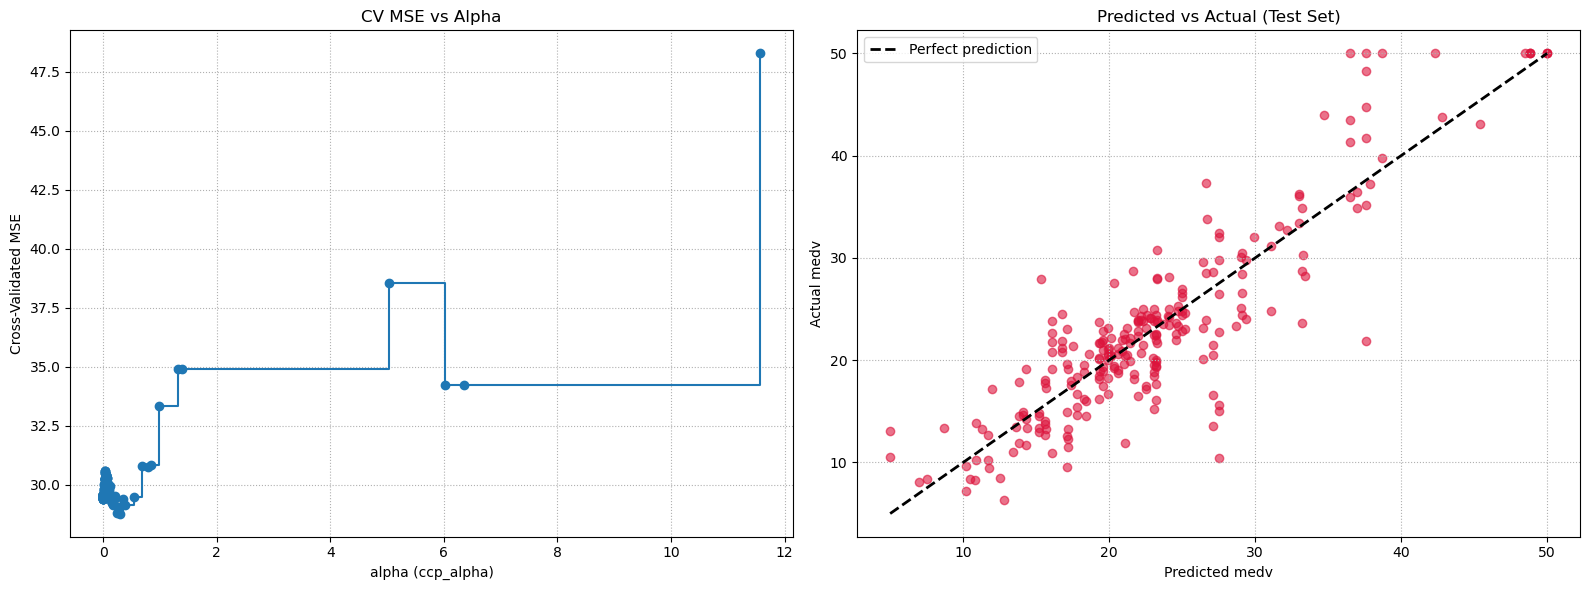

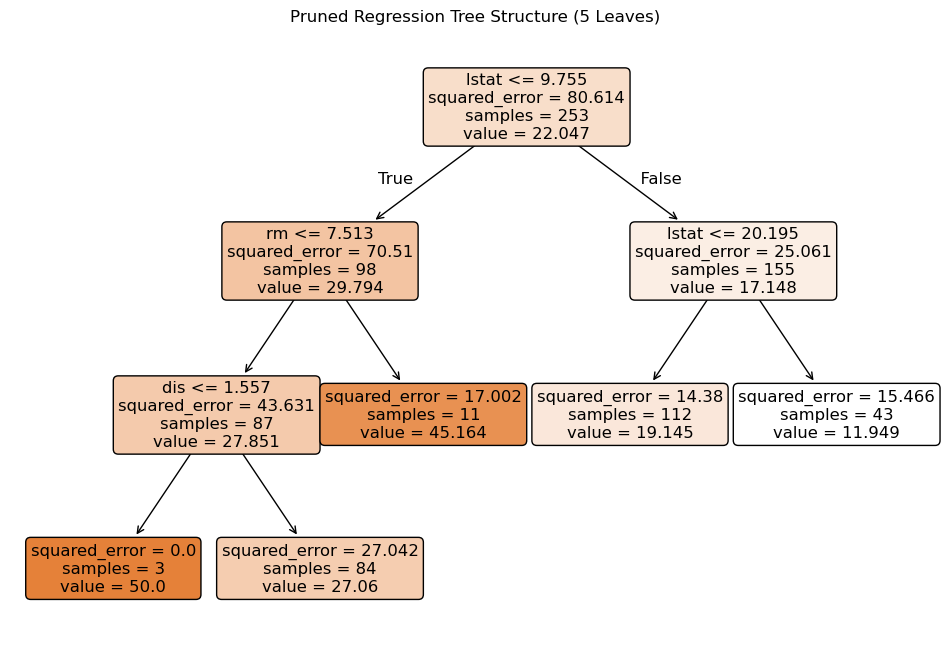

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# 1. Load data Boston
boston = pd.read_csv("data/Boston.csv")

X = boston.drop(columns=["medv"])
y = boston["medv"]

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

# 3. Fit base model
base_reg_tree = DecisionTreeRegressor(criterion="squared_error", random_state=42)
base_reg_tree.fit(X_train, y_train)

print("BASE REGRESSION TREE PERFORMANCE")
print(f"Number of terminal nodes (leaves): {base_reg_tree.get_n_leaves()}")
print(f"Train MSE: {mean_squared_error(y_train, base_reg_tree.predict(X_train)):.4f}")
print(f"Test MSE (Unpruned): {mean_squared_error(y_test, base_reg_tree.predict(X_test)):.4f}\n")

# 4. Select best alpha (Cost Complexity Pruning)
path = base_reg_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

kf = KFold(n_splits=5, shuffle=True, random_state=1)
alpha_mse_scores = []

for alpha in ccp_alphas:
    fold_mses = []
    for train_idx, val_idx in kf.split(X_train):
        clf = DecisionTreeRegressor(criterion="squared_error", ccp_alpha=alpha, random_state=42)
        clf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        
        val_pred = clf.predict(X_train.iloc[val_idx])
        fold_mses.append(mean_squared_error(y_train.iloc[val_idx], val_pred))
        
    alpha_mse_scores.append(np.mean(fold_mses))

# best_alpha = ccp_alphas[np.argmin(alpha_scores)] if "alpha_scores" in locals() else ccp_alphas[np.argmin(alpha_mse_scores)]
best_alpha = ccp_alphas[np.argmin(alpha_mse_scores)]
print("CROSS-VALIDATION RESULTS")
print(f"Best ccp_alpha found: {best_alpha:.6f}")

# 5. Forced tree to prune
pruned_reg_tree = DecisionTreeRegressor(criterion="squared_error", max_leaf_nodes=5, random_state=42)
pruned_reg_tree.fit(X_train, y_train)

print("\nPRUNED REGRESSION TREE (5 LEAVES) PERFORMANCE")
print(f"Number of terminal nodes: {pruned_reg_tree.get_n_leaves()}")
print(f"Test MSE (Pruned): {mean_squared_error(y_test, pruned_reg_tree.predict(X_test)):.4f}\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(ccp_alphas[:-1], alpha_mse_scores[:-1], marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha (ccp_alpha)")
ax[0].set_ylabel("Cross-Validated MSE")
ax[0].set_title("CV MSE vs Alpha")
ax[0].grid(True, ls=":")

y_pred_test = base_reg_tree.predict(X_test)
ax[1].scatter(y_pred_test, y_test, alpha=0.6, color="crimson")
ax[1].plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2, label="Perfect prediction")
ax[1].set_xlabel("Predicted medv")
ax[1].set_ylabel("Actual medv")
ax[1].set_title("Predicted vs Actual (Test Set)")
ax[1].legend()
ax[1].grid(True, ls=":")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plot_tree(pruned_reg_tree, feature_names=X.columns, filled=True, rounded=True)
plt.title("Pruned Regression Tree Structure (5 Leaves)")
plt.show()

The unpruned regression tree grew excessively deep, resulting in 238 terminal nodes, a Train MSE of 0.0000, and a Test MSE of 18.5455. This full tree represents a highly flexible model with high variance.

When we constrained the tree to only 5 terminal nodes, the Test MSE degraded to 27.2481. The reason for this poor performance is underfitting (high bias) rather than overfitting. By forcing such a strict limitation, we made the model too rigid, preventing it from capturing essential non-linear structures in the housing data

The 5-fold cross-validation path successfully identified an optimal tuning parameter of ccp_alpha = 0.300799. As shown in the left-hand cost-complexity chart, the validation error reaches its minimum at a relatively low alpha value before sharply rising as the penalty increases. This proves that while some regularization is required, pruning the model all the way down to 5 leaves introduces too much bias

The prediction scatter plot highlights that the unpruned model performs consistently across mid-range housing values but struggles significantly at the upper bound where Actual medv = 50, caused by the target variable's capping in the original dataset

Structurally, the features lstat (lower socioeconomic status percentage) and rm (average number of rooms) appear at the very top of the tree, confirming they are the most critical drivers of median home value

#### Task 8.3.3 Bagging and Random Forests

BAGGING PERFORMANCE (m=13)
Test MSE: 14.9766
Root MSE: 3.8700

RANDOM FOREST PERFORMANCE (m=6)
Test MSE: 13.3874
Root MSE: 3.6589



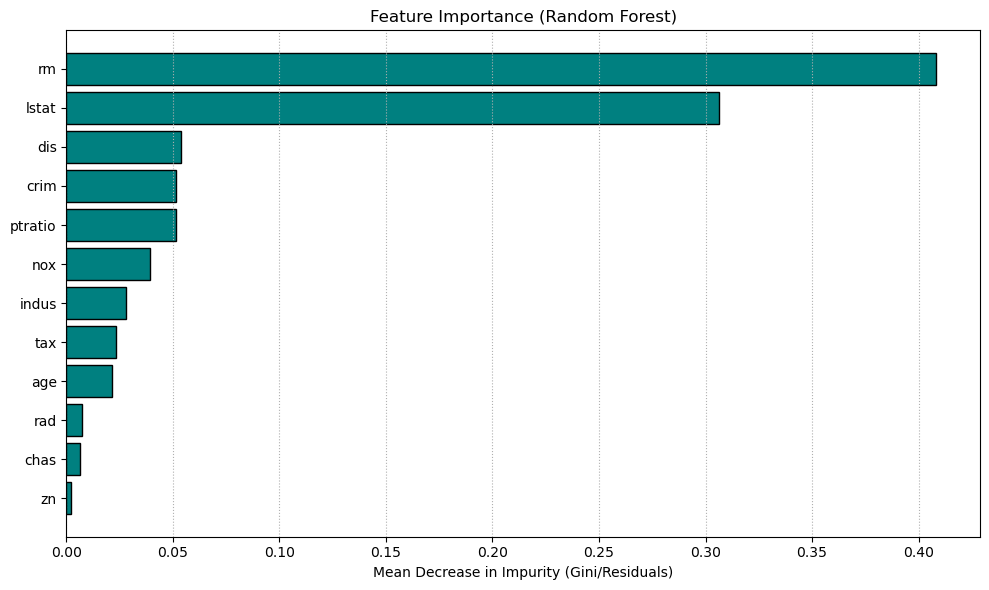

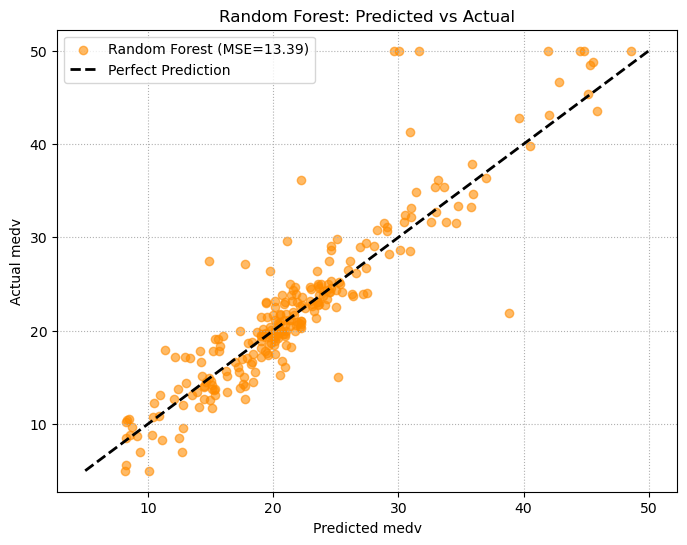

In [17]:
from sklearn.ensemble import RandomForestRegressor

# 1. Load data Boston
boston = pd.read_csv("data/Boston.csv")
boston.drop(columns=["Unnamed: 0"], axis=0, inplace=True)

X = boston.drop(columns=["medv"])
y = boston["medv"]

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 3. BAGGING (m = p = 13)
bag_boston = RandomForestRegressor(n_estimators=500, max_features=13, random_state=42, n_jobs=-1)
bag_boston.fit(X_train, y_train)

y_pred_bag = bag_boston.predict(X_test)
bag_mse = mean_squared_error(y_test, y_pred_bag)

print("BAGGING PERFORMANCE (m=13)")
print(f"Test MSE: {bag_mse:.4f}")
print(f"Root MSE: {np.sqrt(bag_mse):.4f}\n")

# 4. RANDOM FOREST (m = 6)
rf_boston = RandomForestRegressor(n_estimators=500, max_features=6, random_state=42, n_jobs=-1)
rf_boston.fit(X_train, y_train)

y_pred_rf = rf_boston.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)

print("RANDOM FOREST PERFORMANCE (m=6)")
print(f"Test MSE: {rf_mse:.4f}")
print(f"Root MSE: {np.sqrt(rf_mse):.4f}\n")

# 5. VARIABLE IMPORTANCE
importances = rf_boston.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="teal", edgecolor="k")
plt.xlabel("Mean Decrease in Impurity (Gini/Residuals)")
plt.title("Feature Importance (Random Forest)")
plt.grid(axis="x", ls=":")
plt.tight_layout()
plt.show()

# 6. Comparing models
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, y_test, alpha=0.6, color="darkorange", label=f"Random Forest (MSE={rf_mse:.2f})")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2, label="Perfect Prediction")
plt.xlabel("Predicted medv")
plt.ylabel("Actual medv")
plt.title("Random Forest: Predicted vs Actual")
plt.legend()
plt.grid(True, ls=":")
plt.show()

Both ensemble methods substantially outperform the single regression tree, cutting the test error nearly in half. In a direct comparison, the Random Forest approach ($m = 6$) outperformed Bagging ($m = 13$), achieving a lower Test MSE of 13.3874 compared to Bagging's 14.9766. This corresponds to a Root MSE of approximately 3.66, meaning the Random Forest predictions are, on average, within $\$3,660$ of the true median home values

The mathematical intuition behind Random Forest’s superiority lies in its ability to decorrelate individual trees. In Bagging, since all 13 predictors are evaluated at every split, strong dominant features like rm and lstat are consistently selected as top-level splitters across almost all bootstrapped trees. This high structural similarity leads to highly correlated tree predictions, which limits the ensemble's ability to minimize variance during averaging.


By restricting the available feature pool to $m = 6$, Random Forest forces many trees to split on alternative predictors (such as dis or crim), effectively uncovering alternative data interactions and further driving down the overall model variance

As illustrated in the Mean Decrease in Impurity plot, rm (average number of rooms) and lstat (lower socioeconomic status percentage) remain by far the most critical variables driving the predictions. Their dominant status as top predictors remains unchanged from the single-tree experiment, solidifying their role as the primary economic indicators in the Boston housing dataset

### Task 8.3.4 Boosting

BOOSTING PERFORMANCE (lambda = 0.001)
Test MSE: 16.0377

BOOSTING PERFORMANCE (lambda = 0.2)
Test MSE: 15.4031



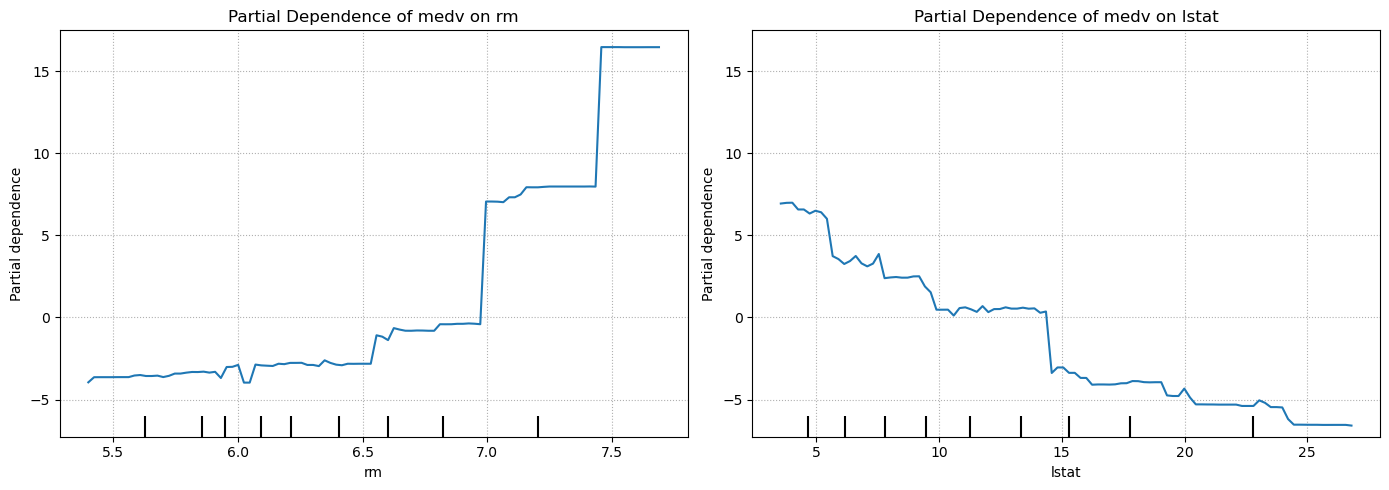

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import PartialDependenceDisplay

# 1. Load data Boston
boston = pd.read_csv("data/Boston.csv")
boston.drop(columns=["Unnamed: 0"], axis=0, inplace=True)

X = boston.drop(columns=["medv"])
y = boston["medv"]

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 3. BOOSTING №1 (learning_rate = 0.001)
boost_boston_1 = GradientBoostingRegressor(n_estimators=5000, learning_rate=0.001, 
                                           max_depth=4, random_state=42)
boost_boston_1.fit(X_train, y_train)

y_pred_boost_1 = boost_boston_1.predict(X_test)
boost_mse_1 = mean_squared_error(y_test, y_pred_boost_1)

print("BOOSTING PERFORMANCE (lambda = 0.001)")
print(f"Test MSE: {boost_mse_1:.4f}\n")

# 4. BOOSTING №2 (learning_rate = 0.2)
boost_boston_2 = GradientBoostingRegressor(n_estimators=5000, learning_rate=0.2, 
                                           max_depth=4, random_state=42)
boost_boston_2.fit(X_train, y_train)

y_pred_boost_2 = boost_boston_2.predict(X_test)
boost_mse_2 = mean_squared_error(y_test, y_pred_boost_2)

print("BOOSTING PERFORMANCE (lambda = 0.2)")
print(f"Test MSE: {boost_mse_2:.4f}\n")

# 5. PARTIAL DEPENDENCE PLOTS
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
PartialDependenceDisplay.from_estimator(boost_boston_2, X_train, features=["rm", "lstat"], ax=ax)
ax[0].set_title("Partial Dependence of medv on rm")
ax[0].grid(True, ls=":")
ax[1].set_title("Partial Dependence of medv on lstat")
ax[1].grid(True, ls=":")
plt.tight_layout()
plt.show()

The gradient boosting model trained with a higher shrinkage parameter ($\lambda = 0.2$) yielded a better test error with a Test MSE of 15.4031, compared to 16.0377 when using $\lambda = 0.001$. While a larger learning rate combined with 5000 trees generally introduces a severe risk of overfitting (high variance), the model with $\lambda = 0.001$ suffered from underfitting. A step size of 0.001 was too conservative for 5000 estimators to fully minimize the empirical loss, leaving room for optimization. On this specific data split, Random Forest remains the superior architecture, maintaining the lowest overall error (Test MSE: 13.3874).

The partial dependence plots successfully illustrate the marginal non-linear effects of the top two features on the target variable:
- medv vs rm (Left Plot): A clear positive relationship is visible; as the average number of rooms increases, the median home value rises. However, this effect is highly non-linear and exhibits a distinct step-function behavior, showing substantial price surges at specific thresholds, notably around rm >= 7.0 and rm >= 7.4
- medv vs lstat (Right Plot): Conversely, there is a strong negative relationship. As the percentage of lower socioeconomic status households increases, the predicted property values systematically drop. Rather than being strictly linear, this decline is characterized by sharp drops at critical demographic tipping points (e.g., around 10% and 15% lstat)

### Exercise

### Task 7

Number of features : 12
Running experiment for: Random Forest (mtry=3)
Running experiment for: Random Forest (mtry=6)
Running experiment for: Bagging (mtry=12)


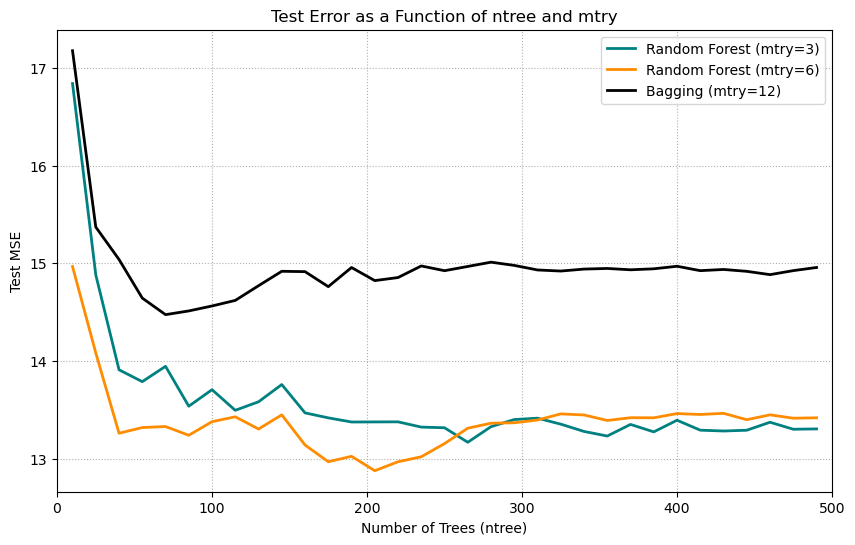

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Load data Boston
boston = pd.read_csv("data/Boston.csv")
boston.drop(columns=["Unnamed: 0"], axis=0, inplace=True)

X =  boston.drop(columns=["medv"])
y =  boston["medv"]

p = X.shape[1] 
print(f"Number of features : {p}")

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 3. Settings
ntree_range = np.arange(10, 501, 15) 

mtry_values = [3, 6, p]
labels = ["Random Forest (mtry=3)", "Random Forest (mtry=6)", f"Bagging (mtry={p})"]
colors = ["teal", "darkorange", "black"]

plt.figure(figsize=(10, 6))

# 4. Start process
for mtry, label, color in zip(mtry_values, labels, colors):
    test_errors = []
    print(f"Running experiment for: {label}")
    
    for ntree in ntree_range:
        rf = RandomForestRegressor(
            n_estimators=ntree, 
            max_features=mtry, 
            random_state=42, 
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        
        preds = rf.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        test_errors.append(mse)
    
    plt.plot(ntree_range, test_errors, label=label, color=color, lw=2)

plt.xlabel("Number of Trees (ntree)")
plt.ylabel("Test MSE")
plt.title("Test Error as a Function of ntree and mtry")
plt.grid(True, ls=":")
plt.legend(frameon=True)
plt.xlim(0, 500)

plt.show()

The plot clearly indicates that for all choices of mtry, the Test MSE drops drastically at the beginning of the training phase. The major improvements in model performance are achieved within the region of 50 trees. Beyond this point, adding more estimators yields diminishing returns, and the error curves enter a stable plateau. This demonstrates a key theoretical advantage of tree-based ensembles: they do not overfit as the number of trees grows large.

The model with mtry = 6 achieves the best overall performance, reaching its global minimum Test MSE around 200 trees. Conversely, Bagging (mtry = 12) shows the worst performance across the entire range of ntree

The suboptimal performance of Bagging is directly linked to the underlying mathematics of the algorithm. Because Bagging considers all p=12 features at every single split, strong dominant predictors (such as rm or lstat) are chosen repeatedly across different bootstrap samples. This makes the individual trees in the ensemble highly correlated. As a result, averaging their predictions does not decrease the variance as effectively as Random Forest does. By restricting mtry to 3 or 6, Random Forest forces different trees to perform splits on alternative features, successfully decorrelates the trees, and significantly lowers the overall Test MSE

### Task 8
In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

   Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  Education Urban   US
0   9.50        138      73           11         276    120       Bad   42         17   Yes  Yes
1  11.22        111      48           16         260     83      Good   65         10   Yes  Yes
2  10.06        113      35           10         269     80    Medium   59         12   Yes  Yes
3   7.40        117     100            4         466     97    Medium   55         14   Yes  Yes
4   4.15        141      64            3         340    128       Bad   38         13   Yes   No
Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object
Base Tree Test MSE: 6.9443


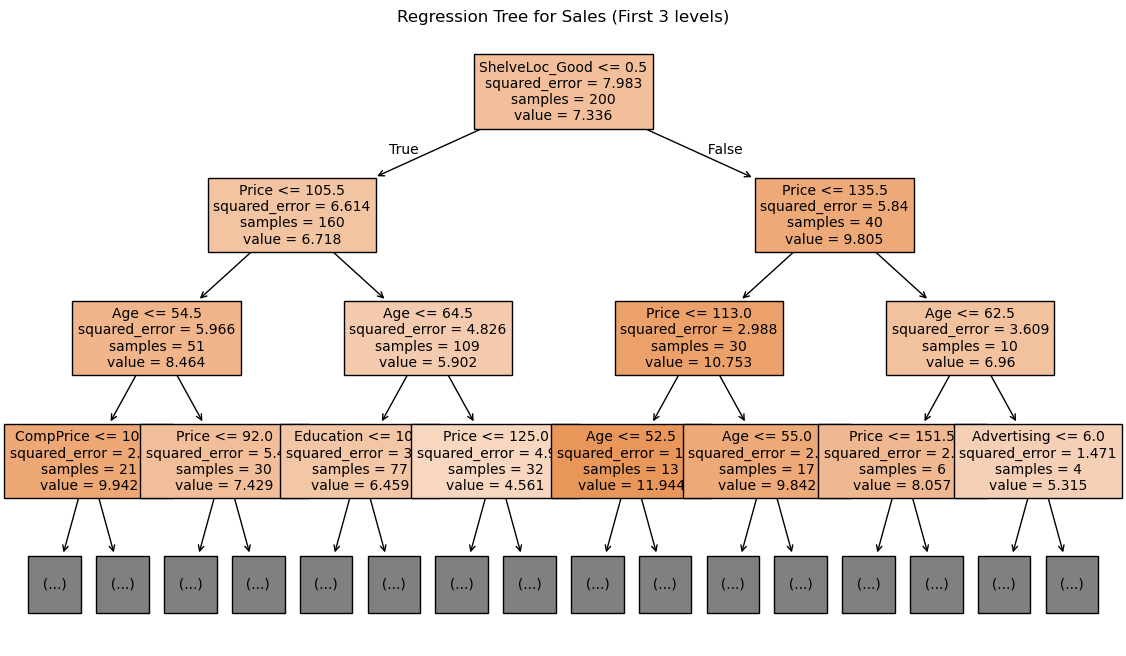

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

# Load data Carseats
carseats = pd.read_csv("data/Carseats.csv")

print(carseats.head())
print(carseats.dtypes)

# 1. Coding categorical features
df_encoded = pd.get_dummies(carseats, columns=["ShelveLoc", "Urban", "US"], drop_first=True, dtype=int)

X = df_encoded.drop(columns=["Sales"])
y = df_encoded["Sales"]

# (a) Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# (b) Fit a regression tree to the training set
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

preds = tree_model.predict(X_test)
base_mse = mean_squared_error(y_test, preds)
print(f"Base Tree Test MSE: {base_mse:.4f}")

plt.figure(figsize=(14, 8))
plot_tree(tree_model, max_depth=3, feature_names=X.columns, filled=True, fontsize=10)
plt.title("Regression Tree for Sales (First 3 levels)")
plt.show()

The regression tree indicates that the most critical predictor for unit sales is ShelveLoc_Good (the quality of the shelving location), which serves as the root split. For stores without a good shelf location, Price becomes the secondary deciding factor, whereas for stores with high-quality placement, Price and Age dominate the subsequent splits.

The unpruned decision tree achieves a Test MSE of 6.9443. Given that the response variable Sales is measured in thousands of units, the Root Mean Squared Error $(\text{RMSE} = \sqrt{6.9443} \approx 2.635)$ implies an average prediction error of approximately 2635 car seats. Considering the average sales volume typically falls around 7,000–8,000 units, this error rate is quite substantial, highlighting that a single fully-grown tree suffers from high variance and overfits the training data

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {"ccp_alpha": np.linspace(0, 0.05, 50)}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
print(f"Optimal alpha: {grid_search.best_params_["ccp_alpha"]:.5f}")

pruned_preds = best_tree.predict(X_test)
pruned_mse = mean_squared_error(y_test, pruned_preds)
print(f"Pruned Tree Test MSE: {pruned_mse:.4f}")

Optimal alpha: 0.02959
Pruned Tree Test MSE: 5.9226


Through 5-fold cross-validation, the optimal cost-complexity pruning parameter was found to be $\alpha$ $\approx 0.02959$

Applying cost-complexity pruning successfully improved the model's performance on unseen data, reducing the Test MSE from 6.9443 down to 5.9226 (an approximate 14.7% reduction in error)

This improvement confirms that the initial, fully-grown regression tree was overfitted and suffered from high variance. Trimming back the sub-trees that did not contribute significantly to reducing cross-validation error allowed the model to generalize much better to the test set

In [19]:
from sklearn.ensemble import RandomForestRegressor

# (d)
bagging_model = RandomForestRegressor(
    n_estimators=500,
    max_features=None,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train, y_train)

bag_preds = bagging_model.predict(X_test)
bag_mse = mean_squared_error(y_test, bag_preds)
print(f"Bagging Test MSE: {bag_mse:.4f}")

importances = bagging_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Bagging):")
print(importance_df)

Bagging Test MSE: 2.9306

Feature Importances (Bagging):
             Feature  Importance
4              Price    0.335330
5                Age    0.164324
7     ShelveLoc_Good    0.155531
0          CompPrice    0.091085
2        Advertising    0.081307
1             Income    0.049759
3         Population    0.042006
6          Education    0.037170
8   ShelveLoc_Medium    0.030715
9          Urban_Yes    0.007875
10            US_Yes    0.004897


The Bagging approach yielded a Test MSE of 2.9306, representing a dramatic performance leap compared to both the unpruned and pruned single decision trees

Employing bagging allowed the model to substantially decrease variance by averaging 500 unpruned trees grown on bootstrap samples. This reduction in variance directly translates into a much lower test error rate and improved generalization

According to the mean decrease in impurity, the three most important variables driving Sales are Price (0.335), Age (0.164), and ShelveLoc_Good (0.155). This aligns with the root splits observed in our initial standalone tree, but provides a more robust and continuous ranking of feature contributions

In [20]:
# (e) Use random forests with m = p/3 = 4
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_features=4,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_preds)
print(f"Random Forest (m=4) Test MSE: {rf_mse:.4f}")

rf_importances = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Random Forest):")
print(rf_importance_df)

Random Forest (m=4) Test MSE: 3.0946

Feature Importances (Random Forest):
             Feature  Importance
4              Price    0.274950
5                Age    0.162333
7     ShelveLoc_Good    0.133126
2        Advertising    0.092383
0          CompPrice    0.088598
1             Income    0.075024
3         Population    0.069054
6          Education    0.050092
8   ShelveLoc_Medium    0.030793
10            US_Yes    0.012308
9          Urban_Yes    0.011340


The Random Forest model with m = 4 yielded a Test MSE of 3.0946. In this specific scenario, restricting the feature space at each split did not surpass the Bagging approach (Test MSE = 2.9306)

Restricting m to 4 significantly altered the distribution of feature weights. While the top three features remain Price (0.275), Age (0.162), and ShelveLoc_Good (0.133), the absolute dominance of Price decreased. The gap between the first and second most important features shrank from 0.171 in Bagging to 0.112 in Random Forest. Concurrently, secondary predictors like Income and Population gained more weight

This outcome perfectly demonstrates the trade-off inherent to Random Forests. Typically, reducing m decorrelates the trees, which reduces the ensemble's variance. However, in this dataset, Price is such an overwhelmingly powerful and crucial predictor for Sales that excluding it from a large portion of the splitting opportunities slightly increases the model's bias. For this particular distribution, the benefit of variance reduction was overridden by the loss of this critical feature, making the slightly less restricted Bagging approach optimal

### Task 9
This problem involves the OJ data set which is part of the ISLR
package.

Training Error Rate: 0.0125
Number of terminal nodes (leaves): 174

Detailed Text Output (First 3 levels)
|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- STORE <= 1.50
|   |   |   |--- ListPriceDiff <= 0.13
|   |   |   |   |--- class: CH
|   |   |   |--- ListPriceDiff >  0.13
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- STORE >  1.50
|   |   |   |--- WeekofPurchase <= 267.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- WeekofPurchase >  267.50
|   |   |   |   |--- truncated branch of depth 4
|   |--- LoyalCH >  0.28
|   |   |--- PriceDiff <= 0.05
|   |   |   |--- SpecialCH <= 0.50
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- SpecialCH >  0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- PriceDiff >  0.05
|   |   |   |--- StoreID <= 3.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- StoreID >  3.50
|   |   |   |   |--- truncated branch of depth 9
|--- LoyalCH >  0.50
|   |--- Loy

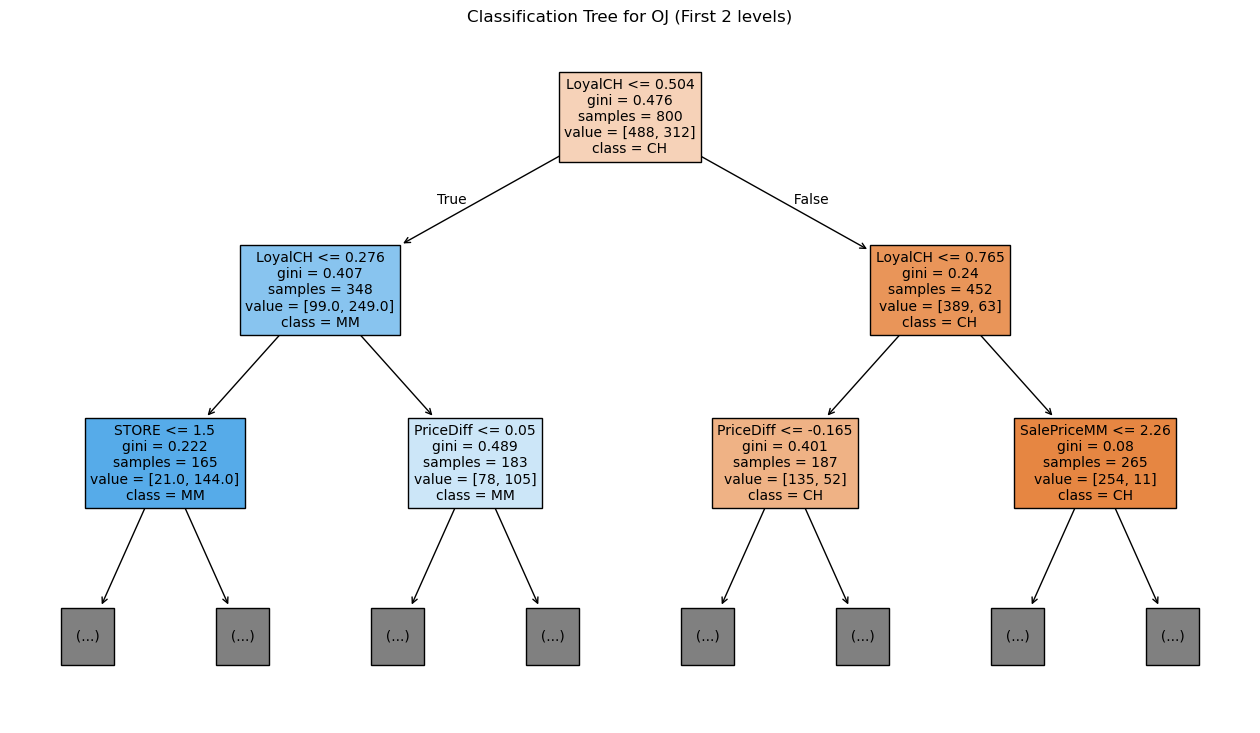

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

# 1. Load data OJ
df = pd.read_csv("data/OJ.csv")

df_encoded = pd.get_dummies(df, columns=["Store7"], drop_first=True, dtype=int)

X = df_encoded.drop(columns=["Purchase"])
y = df_encoded["Purchase"]

# (a) Create a training set containing a random sample of 800 observations
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=800, random_state=42, stratify=y)

# (b) Fit a tree to the training data
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

train_preds = tree_clf.predict(X_train)
train_error_rate = 1 - accuracy_score(y_train, train_preds)
num_leaves = tree_clf.get_n_leaves()

print(f"Training Error Rate: {train_error_rate:.4f}")
print(f"Number of terminal nodes (leaves): {num_leaves}")

# (c) Detailed text output for interpretation
text_representation = export_text(tree_clf, feature_names=list(X.columns), max_depth=3)
print("\nDetailed Text Output (First 3 levels)")
print(text_representation)

# (d) Create a plot of the tree
plt.figure(figsize=(16, 9))
plot_tree(
    tree_clf, 
    max_depth=2,
    feature_names=X.columns, 
    class_names=tree_clf.classes_, 
    filled=True, 
    fontsize=10
)
plt.title("Classification Tree for OJ (First 2 levels)")
plt.show()

Training Error Rate: 0.0125 (or 1.25\%).

Number of Terminal Nodes: 174 leaves

While the training error rate is extremely low, this is a clear symptom of overfitting. Because no regularization or tree-depth constraints were applied, the tree grew excessively complex, capturing random noise in the training set rather than just generalizable patterns

If a customer has exceptionally high brand loyalty to Citrus Hill (LoyalCH > 0.86) and the price of the competing Minute Maid juice is high (SalePriceMM > 2.26), the tree predicts with high certainty that the customer will purchase Citrus Hill (CH)

The tree visualization confirms that LoyalCH is the single most essential predictor. It serves as the root split at threshold 0.504, and immediately splits the data again on the second level (at thresholds 0.276 and 0.765 for the left and right branches respectively). Customer loyalty carries far more predictive power than physical store metrics or minor price fluctuations

Unpruned Tree Test Error Rate: 0.2333

Confusion Matrix:
[[137  28]
 [ 35  70]]


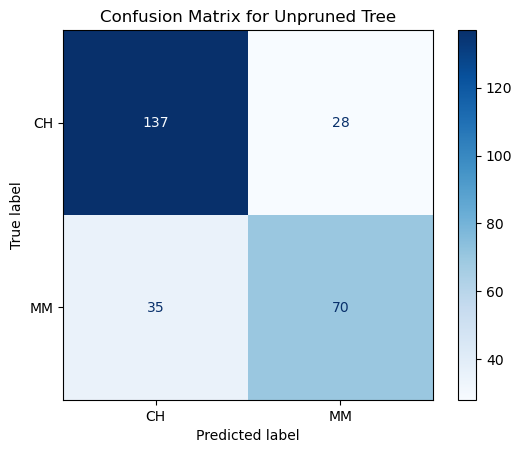

In [26]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# (e) Predict response on test data
test_preds = tree_clf.predict(X_test)

# Считаем Test Error Rate (1 - Accuracy)
test_error_rate = 1 - accuracy_score(y_test, test_preds)
print(f"Unpruned Tree Test Error Rate: {test_error_rate:.4f}")

cm = confusion_matrix(y_test, test_preds, labels=tree_clf.classes_)
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Unpruned Tree")
plt.show()

Test Error Rate: 0.2333 (or 23.33%).

As anticipated, the test error rate is significantly higher than the training error rate (1.25%). This severe performance drop confirms that the unpruned tree suffered from high variance and was overfitted to the training sample

Out of 270 test observations, the model made 63 misclassifications. Specifically, it committed 28 False Positive errors (predicting Minute Maid when the actual choice was Citrus Hill) and 35 False Negative errors. The model is somewhat overly aggressive in switching boundaries, failing to establish stable decision paths due to the immense complexity of having 174 terminal nodes

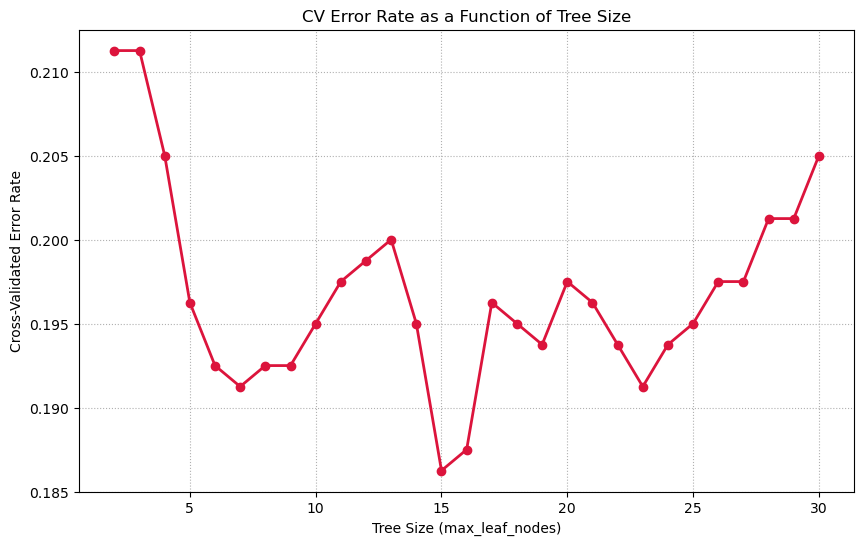

Optimal tree size (lowest CV error): 15


In [27]:
from sklearn.model_selection import GridSearchCV

# (f)
param_grid = {"max_leaf_nodes": np.arange(2, 31)}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# (g)
cv_errors = 1 - grid_search.cv_results_["mean_test_score"]
tree_sizes = param_grid["max_leaf_nodes"]

# (g) Produce a plot with tree size on the x-axis and CV error rate on the y-axis
plt.figure(figsize=(10, 6))
plt.plot(tree_sizes, cv_errors, marker="o", color="crimson", lw=2)
plt.xlabel("Tree Size (max_leaf_nodes)")
plt.ylabel("Cross-Validated Error Rate")
plt.title("CV Error Rate as a Function of Tree Size")
plt.grid(True, ls=":")
plt.show()

# (h) Which tree size corresponds to the lowest error rate?
best_size = grid_search.best_params_["max_leaf_nodes"]
print(f"Optimal tree size (lowest CV error): {best_size}")

The optimal amount of leafs is 15.

In [28]:
# (i) Produce a pruned tree corresponding to the optimal tree size (15 terminal nodes)
pruned_clf = DecisionTreeClassifier(max_leaf_nodes=15, random_state=42)
pruned_clf.fit(X_train, y_train)

# (j) Compare training error rates
pruned_train_preds = pruned_clf.predict(X_train)
pruned_train_error = 1 - accuracy_score(y_train, pruned_train_preds)

print(f"Unpruned Tree Training Error Rate: {train_error_rate:.4f} (Nodes: {tree_clf.get_n_leaves()})")
print(f"Pruned Tree Training Error Rate:   {pruned_train_error:.4f} (Nodes: 15)")

# (k) Compare test error rates
pruned_test_preds = pruned_clf.predict(X_test)
pruned_test_error = 1 - accuracy_score(y_test, pruned_test_preds)

print(f"\nUnpruned Tree Test Error Rate:{test_error_rate:.4f}")
print(f"Pruned Tree Test Error Rate:{pruned_test_error:.4f}")

Unpruned Tree Training Error Rate: 0.0125 (Nodes: 174)
Pruned Tree Training Error Rate:   0.1412 (Nodes: 15)

Unpruned Tree Test Error Rate:0.2333
Pruned Tree Test Error Rate:0.1519


Based on the 5-fold cross-validation plot, the lowest classification error rate is achieved at 15 terminal nodes. Beyond 15 leaves, the cross-validated error rate begins to climb back up, demonstrating the point where the model starts overfitting the training data

The training error rate for the unpruned tree is 0.0125 (174 nodes), whereas the pruned tree yields a higher training error rate of 0.1412 (15 nodes).

The unpruned tree results in a test error rate of 0.2333, while the pruned tree achieves a significantly lower test error rate of 0.1519

The unpruned tree has a lower training error rate because it was allowed to grow without constraints, memorizing noise. However, the pruned tree performs substantially better on the test data. Employing cost-complexity pruning successfully decreased the variance of the model by selecting the proper amount of terminal nodes, reducing the test error rate by approximately 35%.

### Task 10
We now use boosting to predict Salary in the Hitters data set

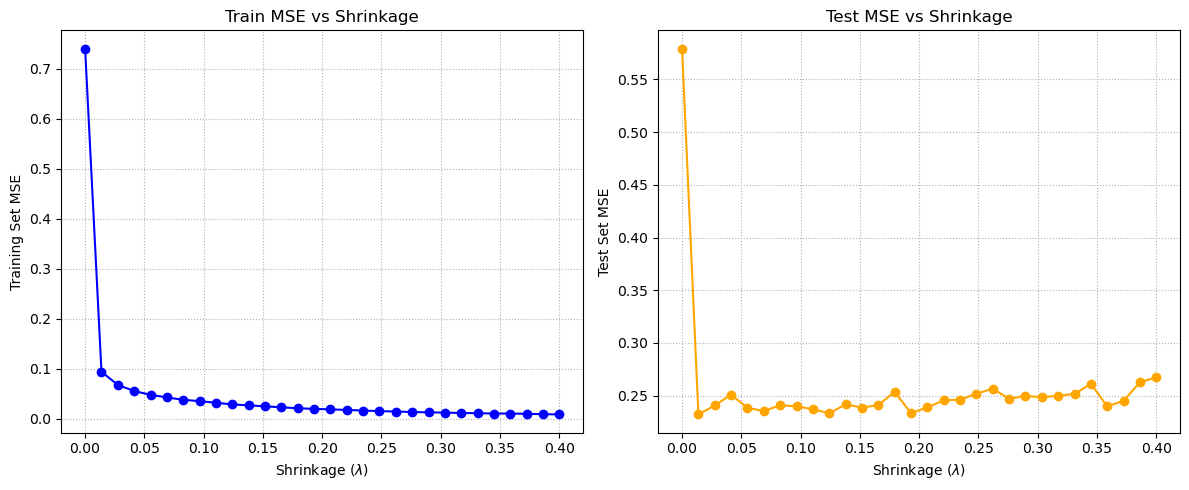

Minimum Test MSE: 0.2323 at shrinkage: 0.0139


In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# 1. Load data Hitters.csv
hitters = pd.read_csv("data/Hitters.csv")

# (a) Remove observations where Salary is unknown (NaN) and log-transform Salary
hitters = hitters.dropna(subset=["Salary"])
hitters["Salary"] = np.log(hitters["Salary"])

hitters_encoded = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

X = hitters_encoded.drop(columns=["Salary"])
y = hitters_encoded["Salary"]

# (b) Create a training set consisting of the FIRST 200 observations, and test set for the rest
X_train = X.iloc[:200]
y_train = y.iloc[:200]
X_test = X.iloc[200:]
y_test = y.iloc[200:]

# (c) & (d) Perform boosting with 1,000 trees for a range of shrinkage values (learning_rate)
shrinkage_values = np.linspace(0.0001, 0.4, 30)

train_mses = []
test_mses = []

for lr in shrinkage_values:
    gb = GradientBoostingRegressor(n_estimators=1000, learning_rate=lr, max_depth=1, random_state=42)
    gb.fit(X_train, y_train)
    
    train_preds = gb.predict(X_train)
    train_mses.append(mean_squared_error(y_train, train_preds))
    
    test_preds = gb.predict(X_test)
    test_mses.append(mean_squared_error(y_test, test_preds))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(shrinkage_values, train_mses, color="blue", marker="o", ls="-")
plt.xlabel("Shrinkage ($\lambda$)")
plt.ylabel("Training Set MSE")
plt.title("Train MSE vs Shrinkage")
plt.grid(True, ls=":")

plt.subplot(1, 2, 2)
plt.plot(shrinkage_values, test_mses, color="orange", marker="o", ls="-")
plt.xlabel("Shrinkage ($\lambda$)")
plt.ylabel("Test Set MSE")
plt.title("Test MSE vs Shrinkage")
plt.grid(True, ls=":")

plt.tight_layout()
plt.show()

best_idx = np.argmin(test_mses)
print(f"Minimum Test MSE: {test_mses[best_idx]:.4f} at shrinkage: {shrinkage_values[best_idx]:.4f}")

As the shrinkage parameter ($\lambda$) increases, the Training MSE decreases monotonically, approaching near-zero levels. A higher learning rate forces the boosting algorithm to correct previous residual errors more aggressively, leading to a tighter fit on the training sample

The Test MSE does not follow a strictly decreasing trend. It reaches a global minimum of 0.2323 at $\lambda$ $\approx 0.0139$. Beyond this optimal learning rate, the test error begins to exhibit an upward trajectory with subtle fluctuations. This confirms that a relatively high shrinkage parameter introduces overfitting, where 1,000 trees overly memorize training noise at the expense of generalizability

In [35]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor

best_gb = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.0139, max_depth=1, random_state=42)
best_gb.fit(X_train, y_train)

# (e) Linear method
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_mse = mean_squared_error(y_test, lr_model.predict(X_test))

# 2. Ridge
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 100))
ridge_model.fit(X_train, y_train)
ridge_mse = mean_squared_error(y_test, ridge_model.predict(X_test))

print(f"Linear Regression (OLS) Test MSE:{lr_mse:.4f}")
print(f"Ridge Regression Test MSE:{ridge_mse:.4f}")
print(f"Best Boosting Test MSE:{test_mses[best_idx]:.4f}")

# (f) Feature importance
gb_importances = best_gb.feature_importances_
gb_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Important Features (Boosting):")
print(gb_importance_df.head(5))

# (g) Bagging
bag_model = RandomForestRegressor(n_estimators=1000, max_features=None, random_state=42, n_jobs=-1)
bag_model.fit(X_train, y_train)
bag_mse = mean_squared_error(y_test, bag_model.predict(X_test))
print(f"\nBagging Test MSE:{bag_mse:.4f}")

Linear Regression (OLS) Test MSE:0.4918
Ridge Regression Test MSE:0.5026
Best Boosting Test MSE:0.2323

Top 5 Important Features (Boosting):
   Feature  Importance
7   CAtBat    0.358003
8    CHits    0.130984
10   CRuns    0.094267
12  CWalks    0.086011
9   CHmRun    0.067673

Bagging Test MSE:0.2290


Linear Regression (OLS) Test MSE: 0.4918

Ridge Regression Test MSE: 0.5026

Best Boosting Test MSE: 0.2323

Both tree-based ensemble methods dramatically outperform the linear models. The substantial drop in Test MSE demonstrates that the relationship between a player's statistics and their log-transformed salary is highly non-linear, which traditional linear or regularized regression approaches fail to capture effectively

The single most critical predictor identified by the boosted model is CAtBat (0.358), followed by CHits (0.131) and CRuns (0.094)

It is highly notable that the top 5 most important features are all career-level metrics (indicated by the 'C' prefix). This implies that long-term historical performance and career longevity are the primary drivers of a player's financial compensation, rather than just their performance in the single current season

Bagging Test MSE: 0.2290

For this specific dataset partition, the Bagging approach achieved the lowest overall test error rate, slightly outperforming the optimized Gradient Boosting model (0.2323). Both approaches, however, showcase the immense power of aggregation over single-model estimation

### Task 11
This question uses the Caravan data set.

In [40]:
from sklearn.ensemble import GradientBoostingClassifier
# 1. Load data Caravan
caravan = pd.read_csv("data/Caravan.csv")

caravan["Purchase"] = caravan["Purchase"].map({"Yes": 1, "No": 0})

X = caravan.drop(columns=["Purchase"])
y =caravan["Purchase"]

# (a) Create a training set consisting of the first 1,000 observations
X_train = X.iloc[:1000]
y_train = y.iloc[:1000]
X_test = X.iloc[1000:]
y_test = y.iloc[1000:]

# (b) Fit a boosting model (1,000 trees, shrinkage = 0.01)
boost_clf = GradientBoostingClassifier(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=1, 
    random_state=42
)
boost_clf.fit(X_train, y_train)

importances = boost_clf.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by='Importance', ascending=False)

print("Top 5 Most Important Predictors:")
print(importance_df.head(5))

# (c) Prediction with a custom threshold of 20%
test_probs = boost_clf.predict_proba(X_test)[:, 1]

custom_preds = (test_probs > 0.20).astype(int)

cm = confusion_matrix(y_test, custom_preds)
print("\nConfusion Matrix (20% Threshold):")
print(cm)

tp = cm[1, 1]
fp = cm[0, 1]
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"\nFraction of predicted purchasers who actually purchased (Precision): {precision:.4f}")

Top 5 Most Important Predictors:
     Feature  Importance
46  PPERSAUT    0.232158
60  PPLEZIER    0.118339
81  APLEZIER    0.091224
42  MKOOPKLA    0.079352
57   PWAOREG    0.050652

Confusion Matrix (20% Threshold):
[[4479   54]
 [ 270   19]]

Fraction of predicted purchasers who actually purchased (Precision): 0.2603


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
lr_probs = log_reg.predict_proba(X_test)[:, 1]
lr_preds = (lr_probs > 0.20).astype(int)
cm_lr = confusion_matrix(y_test, lr_preds)
precision_lr = cm_lr[1, 1] / (cm_lr[1, 1] + cm_lr[0, 1]) if (cm_lr[1, 1] + cm_lr[0, 1]) > 0 else 0

# 2. KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_probs = knn.predict_proba(X_test_scaled)[:, 1]
knn_preds = (knn_probs > 0.20).astype(int)
cm_knn = confusion_matrix(y_test, knn_preds)
precision_knn = cm_knn[1, 1] / (cm_knn[1, 1] + cm_knn[0, 1]) if (cm_knn[1, 1] + cm_knn[0, 1]) > 0 else 0

print(f"Boosting Precision (20%):{precision:.4f}")
print(f"Logistic Reg Precision (20%):{precision_lr:.4f}")
print(f"KNN Precision (20%):{precision_knn:.4f}")

Boosting Precision (20%):0.2603
Logistic Reg Precision (20%):0.1748
KNN Precision (20%):0.1600


The most essential predictors identified by the Gradient Boosting model are PPERSAUT (0.232) and PPLEZIER (0.118).

PPERSAUT represents the contribution for car policies, indicating that customers who already hold or show interest in automobile insurance are the most likely candidates to purchase a Caravan insurance policy

Boosting Performance (20% Threshold): The confusion matrix yields 19 True Positives and 54 False Positives. The fraction of people predicted to make a purchase who actually did so (Precision) is 0.2603 (26.03%).

Gradient Boosting Precision: 26.03%

Logistic Regression Precision: 17.48%

KNN Precision (k=5): 16.00%

While all three models yield seemingly low absolute precision due to the severe class imbalance (where the baseline purchase rate is only $\approx 6%)$, Gradient Boosting significantly outperforms both Logistic Regression and KNN. It improves marketing efficiency more than four-fold over random guessing and provides a 49% relative improvement over the standard logistic approach, proving that tree-based boosting is exceptionally robust at capturing rare target classes in highly skewed datasets